In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image
from sklearn.cluster import KMeans
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

In [2]:
img = Image.open('../../colourful_image.png')
rgb_array = np.array(img)[:, :, :3]
print(rgb_array.shape)

(1328, 2000, 3)


In [3]:
palette = np.array([
    [175, 198, 114],
    [83, 20, 14],
    [185, 49, 40],
    [124, 148, 71]
])

def map_to_palette(image: np.ndarray, palette: np.ndarray) -> np.ndarray:
    output = np.empty_like(image)

    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            pixel = image[y, x].astype(np.int32)  
            diffs = palette.astype(np.int32) - pixel
            distances = np.sum(diffs ** 2, axis=1)

            nearest_idx = np.argmin(distances)
            output[y, x] = palette[nearest_idx]
    return output

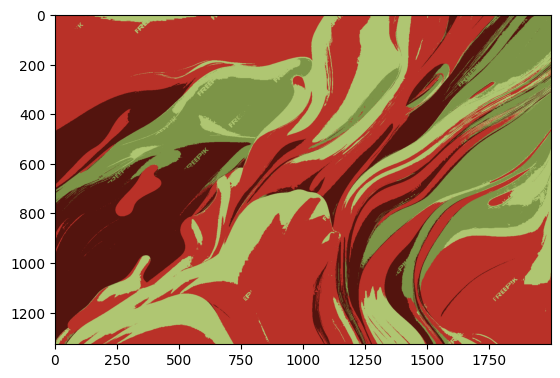

In [4]:
quantized_image = map_to_palette(rgb_array, palette)
plt.imshow(Image.fromarray(quantized_image, 'RGB'))

In [5]:
Image.fromarray(quantized_image, 'RGB').save("color_quantized_palette.png", format="PNG")

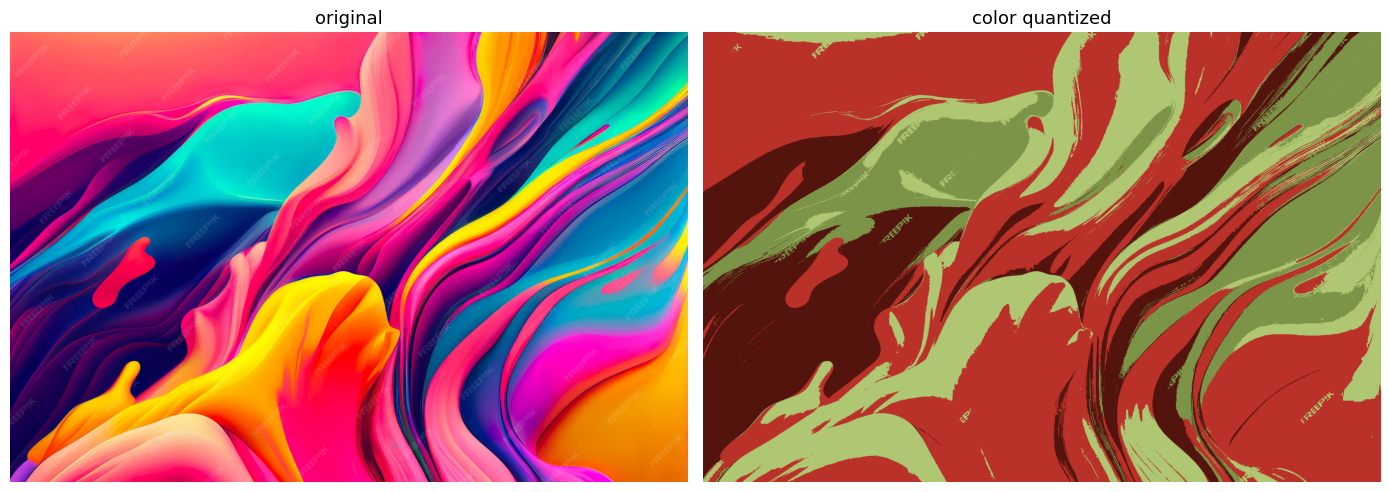

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Original image ---
axes[0].imshow(rgb_array)
axes[0].set_title("original", fontsize=13)
axes[0].axis("off")

# --- Color quantized image ---
axes[1].imshow(quantized_image)
axes[1].set_title("color quantized", fontsize=13)
axes[1].axis("off")

# --- Color palette (vertical) ---
# axes[2].set_title("pallete", fontsize=13)
# axes[2].set_xlim(0, 1)
# axes[2].set_ylim(0, len(palette))
# axes[2].axis("off")

# n = len(palette)
# swatch_h = 0.18      # height of each color block
# gap = (1 - n * swatch_h) / (n + 1)   # even spacing

# for i, color in enumerate(palette):
#     y = 1 - (i + 1) * gap - (i + 1) * swatch_h   # top → bottom

#     rect = mpatches.FancyBboxPatch(
#         (0.05, y), 0.45, swatch_h,
#         boxstyle="round,pad=0.01",
#         color=np.array(color) / 255.0
#     )
#     axes[2].add_patch(rect)

#     axes[2].text(
#         0.55, y + swatch_h / 2,
#         f"R={color[0]}\nG={color[1]}\nB={color[2]}",
#         va="center", ha="left",
#         fontsize=8, family="monospace"
#     )

plt.tight_layout()
plt.show()

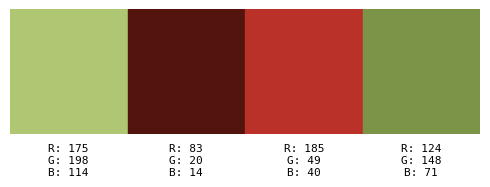

In [23]:
fig, ax = plt.subplots(figsize=(5, 2))
ax.set_xlim(0, len(palette))
ax.set_ylim(0, 1)
ax.axis("off")

for i, color in enumerate(palette):
    rect = mpatches.Rectangle((i, 0), 1, 1, color=np.array(color) / 255.0)
    ax.add_patch(rect)
    ax.text(
        i + 0.5, -0.08,
        f"R: {color[0]}\nG: {color[1]}\nB: {color[2]}",
        va="top", ha="center",
        fontsize=8, family="monospace"
    )

plt.tight_layout()
plt.savefig("palette.png", dpi=130, bbox_inches="tight")
plt.show()

In [8]:
def kmeans_quantize(image_array, n_colors=8):
    pixels = image_array.reshape(-1, 3).astype(np.float32)
    
    # Perform K-Means clustering
    kmeans = KMeans(n_clusters=n_colors, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pixels)
    centers = kmeans.cluster_centers_.astype(np.uint8)
    quantized_pixels = centers[labels].reshape(image_array.shape)
    return quantized_pixels, centers

[[ 48  21 103]
 [249 157  11]
 [ 13 169 188]
 [238  58 127]]


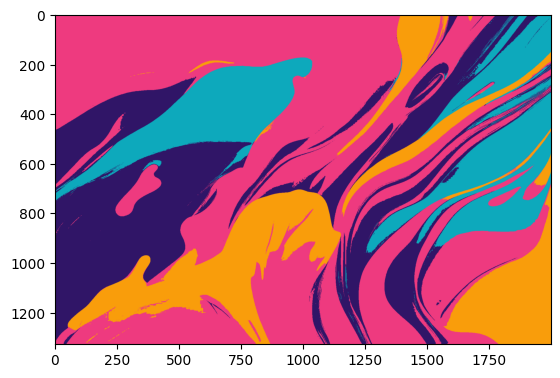

In [25]:
img, optimum_palette = kmeans_quantize(rgb_array, 4)
plt.imshow(Image.fromarray(img, 'RGB'))
print(optimum_palette)

In [26]:
Image.fromarray(img, 'RGB').save("color_quantized_.png", format="PNG")

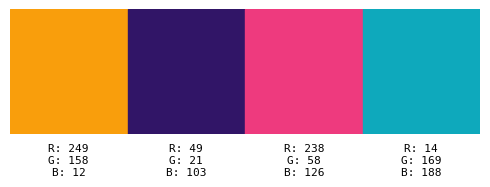

In [22]:
fig, ax = plt.subplots(figsize=(5, 2))
ax.set_xlim(0, len(palette))
ax.set_ylim(0, 1)
ax.axis("off")

for i, color in enumerate(optimum_palette):
    rect = mpatches.Rectangle((i, 0), 1, 1, color=np.array(color) / 255.0)
    ax.add_patch(rect)
    ax.text(
        i + 0.5, -0.08,
        f"R: {color[0]}\nG: {color[1]}\nB: {color[2]}",
        va="top", ha="center",
        fontsize=8, family="monospace"
    )

plt.tight_layout()
plt.savefig("optimum_palette.png", dpi=130, bbox_inches="tight")
plt.show()

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# Utility helpers
# ══════════════════════════════════════════════════════════════════════════════

def resize_image(img: np.ndarray, size=(128, 128)) -> np.ndarray:
    """Nearest-neighbour downscale – no extra deps."""
    h, w = size
    ys = (np.arange(h) * img.shape[0] / h).astype(int)
    xs = (np.arange(w) * img.shape[1] / w).astype(int)
    return img[np.ix_(ys, xs)]


def map_to_palette(image: np.ndarray, palette: np.ndarray) -> np.ndarray:
    """Replace every pixel with the nearest palette colour (vectorised)."""
    H, W, _ = image.shape
    pixels   = image.reshape(-1, 3).astype(np.int32)          # (N, 3)
    pal      = palette.astype(np.int32)                        # (K, 3)
    diffs    = pixels[:, None, :] - pal[None, :, :]           # (N, K, 3)
    dist_sq  = (diffs ** 2).sum(axis=-1)                      # (N, K)
    idx      = dist_sq.argmin(axis=-1)                        # (N,)
    return palette[idx].reshape(H, W, 3).astype(np.uint8)


def mse(image: np.ndarray, palette: np.ndarray) -> float:
    """Mean Squared Error between original and palette-quantized image."""
    quantized = map_to_palette(image, palette.astype(np.uint8))
    return float(np.mean((image.astype(np.float32) - quantized.astype(np.float32)) ** 2))


def palette_swatch(palette: np.ndarray, w=200, h=30) -> np.ndarray:
    """Render a colour palette as an RGB strip."""
    k     = len(palette)
    strip = np.zeros((h, w, 3), dtype=np.uint8)
    for i, colour in enumerate(palette.astype(np.uint8)):
        x0 = int(i * w / k)
        x1 = int((i + 1) * w / k)
        strip[:, x0:x1] = colour
    return strip

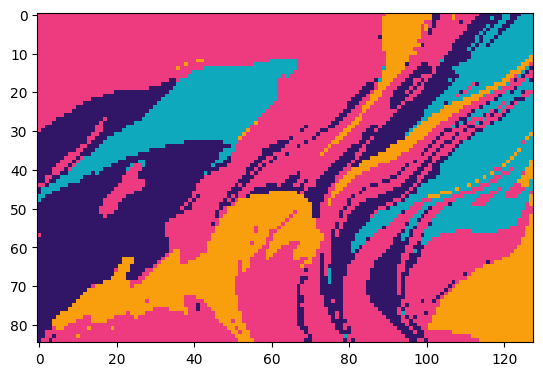

In [12]:
img, optimum_palette = kmeans_quantize(resize_image(rgb_array,(85,128)), 4)
plt.imshow(Image.fromarray(img, 'RGB'))

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# PSO Colour Quantizer
# ══════════════════════════════════════════════════════════════════════════════

class PSOColorQuantizer:
    """
    Particle Swarm Optimisation for colour quantization.

    Particle  : a candidate colour palette  →  shape (n_colors, 3),
                flattened to (n_colors * 3,) for PSO arithmetic.
                Each component is a real value in [0, 255].

    Fitness   : MSE between the original image and the image re-coloured
                using the candidate palette.  Lower  =  better.
    """

    def __init__(
        self,
        image:      np.ndarray,
        n_colors:   int   = 8,
        n_particles:int   = 30,
        max_iter:   int   = 60,
        w:          float = 0.72,   # inertia weight
        c1:         float = 1.49,   # cognitive coefficient
        c2:         float = 1.49,   # social coefficient
        seed:       int   = 42,
    ):
        self.image       = image.astype(np.float32)
        self.n_colors    = n_colors
        self.n_particles = n_particles
        self.max_iter    = max_iter
        self.w, self.c1, self.c2 = w, c1, c2
        self.dim         = n_colors * 3          # solution dimensionality
        self.rng         = np.random.default_rng(seed)

        # ── history (one entry per iteration) ────────────────────────────────
        self.history: list[dict] = []            # list of {iter, positions, pbest_scores, gbest, gbest_score}

    # ── initialise ───────────────────────────────────────────────────────────

    def _init_swarm(self):
        # Seed particles with colours sampled from the image itself
        pixels = self.image.reshape(-1, 3)
        idx    = self.rng.choice(len(pixels), size=(self.n_particles, self.n_colors), replace=True)
        pos    = pixels[idx].reshape(self.n_particles, self.dim)  # (P, D)

        vel    = self.rng.uniform(-20, 20, (self.n_particles, self.dim))
        return pos.copy(), vel

    # ── fitness ──────────────────────────────────────────────────────────────

    def _fitness(self, pos: np.ndarray) -> np.ndarray:
        """Evaluate fitness for every particle.  pos: (P, D)."""
        scores = np.empty(len(pos))
        img_u8 = self.image.astype(np.uint8)
        for i, p in enumerate(pos):
            palette = np.clip(p.reshape(self.n_colors, 3), 0, 255).astype(np.uint8)
            scores[i] = mse(img_u8, palette)
        return scores

    # ── run ──────────────────────────────────────────────────────────────────

    def fit(self):
        pos, vel = self._init_swarm()

        scores   = self._fitness(pos)
        pbest    = pos.copy()
        pbest_sc = scores.copy()

        gbest_idx = np.argmin(pbest_sc)
        gbest     = pbest[gbest_idx].copy()
        gbest_sc  = pbest_sc[gbest_idx]

        for it in range(1, self.max_iter + 1):
            # ── velocity & position update ────────────────────────────────
            r1 = self.rng.random((self.n_particles, self.dim))
            r2 = self.rng.random((self.n_particles, self.dim))
            vel = (
                self.w  * vel
                + self.c1 * r1 * (pbest - pos)
                + self.c2 * r2 * (gbest  - pos)
            )
            pos = np.clip(pos + vel, 0, 255)

            # ── evaluate ─────────────────────────────────────────────────
            scores = self._fitness(pos)

            # ── update personal bests ─────────────────────────────────────
            improved = scores < pbest_sc
            pbest[improved]    = pos[improved]
            pbest_sc[improved] = scores[improved]

            # ── update global best ────────────────────────────────────────
            best_idx = np.argmin(pbest_sc)
            if pbest_sc[best_idx] < gbest_sc:
                gbest    = pbest[best_idx].copy()
                gbest_sc = pbest_sc[best_idx]

            # ── store state ───────────────────────────────────────────────
            self.history.append({
                "iter":        it,
                "positions":   pos.copy(),
                "pbest_scores":pbest_sc.copy(),
                "gbest":       gbest.copy(),
                "gbest_score": gbest_sc,
            })

            if it % 10 == 0:
                print(f"  iter {it:3d}/{self.max_iter}  |  best MSE = {gbest_sc:.2f}")

        self.gbest_palette = np.clip(
            gbest.reshape(self.n_colors, 3), 0, 255
        ).astype(np.uint8)
        return self

    # ── helpers ──────────────────────────────────────────────────────────────

    def palette_at(self, iteration: int) -> np.ndarray:
        state = self.history[iteration - 1]
        return np.clip(state["gbest"].reshape(self.n_colors, 3), 0, 255).astype(np.uint8)

    def mse_curve(self):
        return [h["gbest_score"] for h in self.history]

# ══════════════════════════════════════════════════════════════════════════════
# Visualisation helpers
# ══════════════════════════════════════════════════════════════════════════════

def plot_pso_snapshots(pso: PSOColorQuantizer, image: np.ndarray,
                       snapshots=(1, 10, 30, 60), title=""):
    n = len(snapshots)
    fig = plt.figure(figsize=(5 * n, 7))
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    gs  = gridspec.GridSpec(3, n, height_ratios=[4, 0.6, 1.2], hspace=0.45, wspace=0.15)

    for col, it in enumerate(snapshots):
        it = min(it, pso.max_iter)
        pal = pso.palette_at(it)
        sc  = pso.history[it - 1]["gbest_score"]
        q   = map_to_palette(image, pal)

        ax_img = fig.add_subplot(gs[0, col])
        ax_img.imshow(q)
        ax_img.set_title(f"Iteration {it}\nMSE = {sc:.1f}", fontsize=10)
        ax_img.axis("off")

        ax_sw = fig.add_subplot(gs[1, col])
        ax_sw.imshow(palette_swatch(pal, w=240, h=35))
        ax_sw.axis("off")

        ax_sc = fig.add_subplot(gs[2, col])
        curve = pso.mse_curve()[:it]
        ax_sc.plot(range(1, len(curve) + 1), curve, lw=1.5, color="#e07b39")
        ax_sc.set_xlabel("iteration", fontsize=8)
        ax_sc.set_ylabel("MSE", fontsize=8)
        ax_sc.tick_params(labelsize=7)

    return fig


def plot_comparison(image: np.ndarray, pso: PSOColorQuantizer,
                    km_quantized: np.ndarray, km_palette: np.ndarray,
                    pso_mse: float, km_mse: float, title=""):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    axes[0].imshow(image)
    axes[0].set_title("Original", fontsize=11)
    axes[0].axis("off")

    axes[1].imshow(map_to_palette(image, pso.gbest_palette))
    axes[1].set_title(f"PSO  (MSE = {pso_mse:.1f})", fontsize=11)
    axes[1].axis("off")

    axes[2].imshow(km_quantized)
    axes[2].set_title(f"K-Means  (MSE = {km_mse:.1f})", fontsize=11)
    axes[2].axis("off")

    plt.tight_layout()
    return fig


def plot_mse_curves(pso1, pso2, km_mse1, km_mse2, img_names):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, pso, km_mse, name in zip(axes, [pso1, pso2], [km_mse1, km_mse2], img_names):
        curve = pso.mse_curve()
        ax.plot(range(1, len(curve) + 1), curve, label="PSO best MSE", lw=2, color="#e07b39")
        ax.axhline(km_mse, color="#4a90d9", lw=2, linestyle="--", label=f"K-Means MSE = {km_mse:.1f}")
        ax.set_title(name, fontsize=11)
        ax.set_xlabel("PSO Iteration")
        ax.set_ylabel("MSE")
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    return fig



In [14]:
N_COLORS   = [4, 8]
N_PARTICLES = 30
MAX_ITER   = 100

img_0 = Image.open('image.png')
rgb_array_0 = np.array(img_0)
img_1 = Image.open('../../smol_colours.png')
rgb_array_1 = np.array(img_1)
img_2 = Image.open('../../pixel_art.jpg')
rgb_array_2 = np.array(img_2)
# img_3 = Image.open('../../pixel_art0.jpg')
# rgb_array_3 = np.array(img_3)

images = [rgb_array_0, resize_image(rgb_array, (85, 128)), rgb_array_1, rgb_array_2]
img_titles = ['peppers','colorful', 'very small', 'sunrise pixel art']

In [15]:
# ── run PSO & K-Means on both images ─────────────────────────────────────────

results = []
for name, img in zip(img_titles, images):
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")

    for n in N_COLORS:
        print(f"  Testing with {n} colors:")
        print("  Running PSO …")
        pso = PSOColorQuantizer(img, n_colors=n, n_particles=N_PARTICLES, max_iter=MAX_ITER)
        pso.fit()
        pso_mse_val = pso.history[-1]["gbest_score"]

        print("  Running K-Means …")
        km_q, km_pal = kmeans_quantize(img, n_colors=n)
        km_mse_val   = mse(img, km_pal)

        print(f"  PSO final MSE   : {pso_mse_val:.2f}")
        print(f"  K-Means MSE     : {km_mse_val:.2f}")
        winner = "PSO" if pso_mse_val < km_mse_val else "K-Means"
        print(f"  Better method   : {winner}")

        results.append(dict(name=name+str(n), img=img, pso=pso, km_q=km_q, km_pal=km_pal,
                        pso_mse=pso_mse_val, km_mse=km_mse_val))



  peppers
  Testing with 4 colors:
  Running PSO …
  iter  10/100  |  best MSE = 603.20
  iter  20/100  |  best MSE = 571.08
  iter  30/100  |  best MSE = 543.23
  iter  40/100  |  best MSE = 537.82
  iter  50/100  |  best MSE = 530.71
  iter  60/100  |  best MSE = 526.01
  iter  70/100  |  best MSE = 524.75
  iter  80/100  |  best MSE = 524.36
  iter  90/100  |  best MSE = 524.26
  iter 100/100  |  best MSE = 524.25
  Running K-Means …
  PSO final MSE   : 524.25
  K-Means MSE     : 524.26
  Better method   : PSO
  Testing with 8 colors:
  Running PSO …
  iter  10/100  |  best MSE = 327.29
  iter  20/100  |  best MSE = 298.02
  iter  30/100  |  best MSE = 283.06
  iter  40/100  |  best MSE = 264.56
  iter  50/100  |  best MSE = 257.80
  iter  60/100  |  best MSE = 255.29
  iter  70/100  |  best MSE = 252.35
  iter  80/100  |  best MSE = 252.16
  iter  90/100  |  best MSE = 251.73
  iter 100/100  |  best MSE = 251.34
  Running K-Means …
  PSO final MSE   : 251.34
  K-Means MSE     : 22

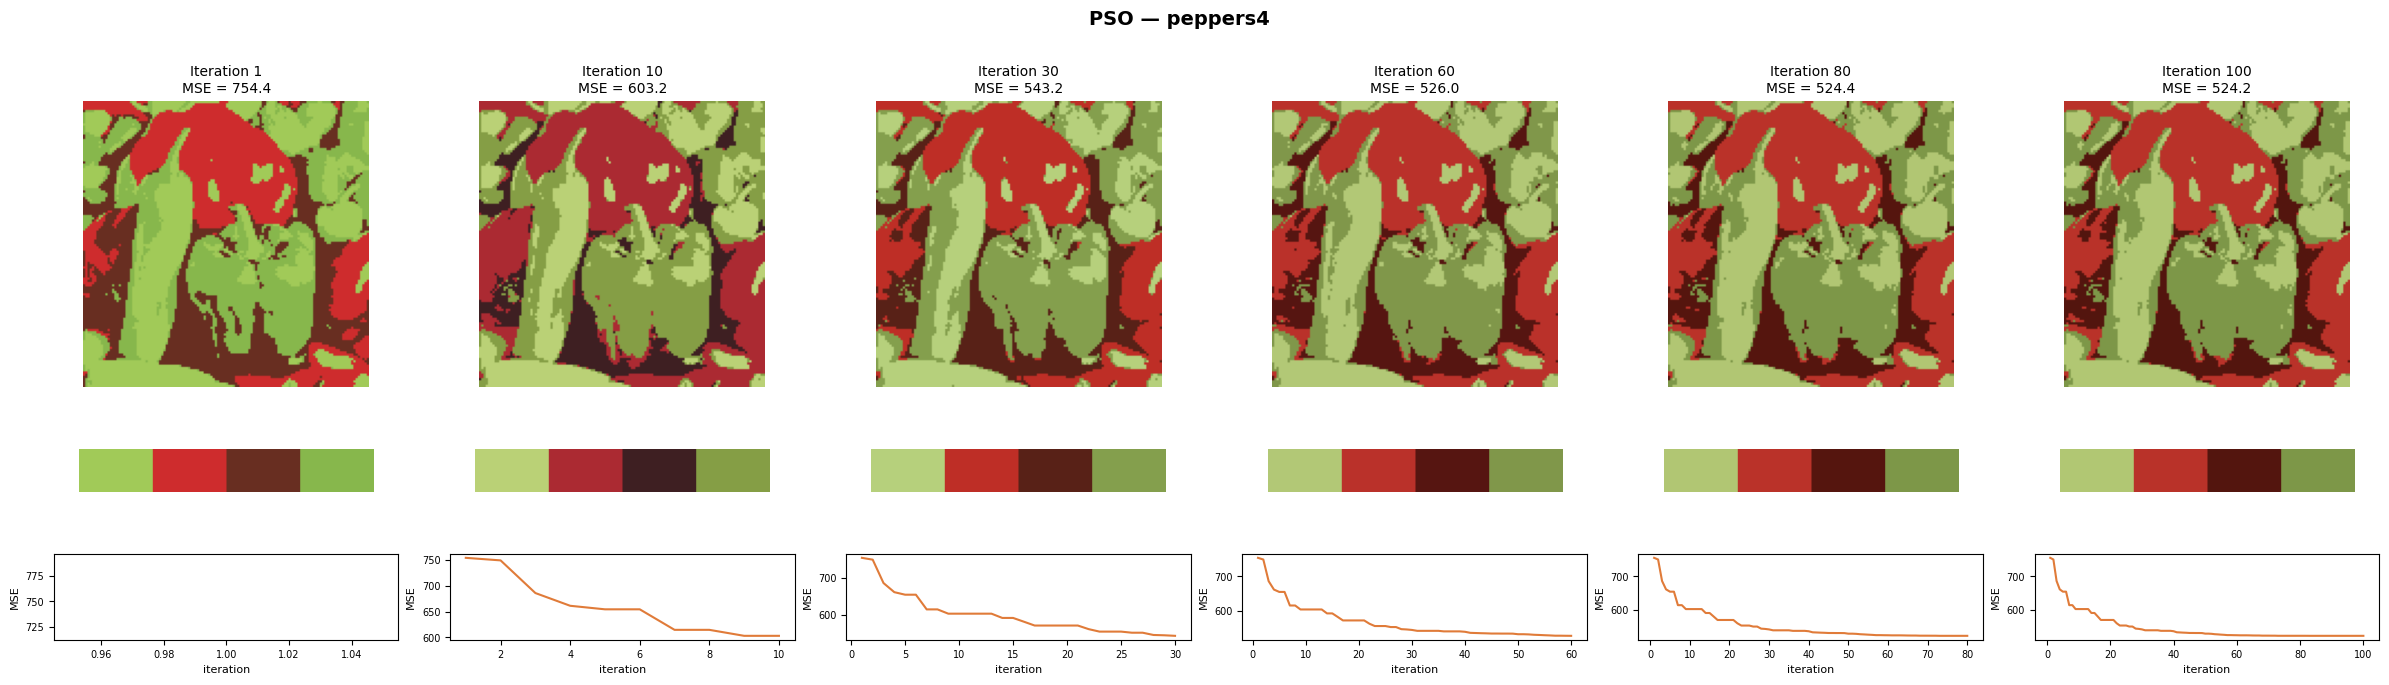

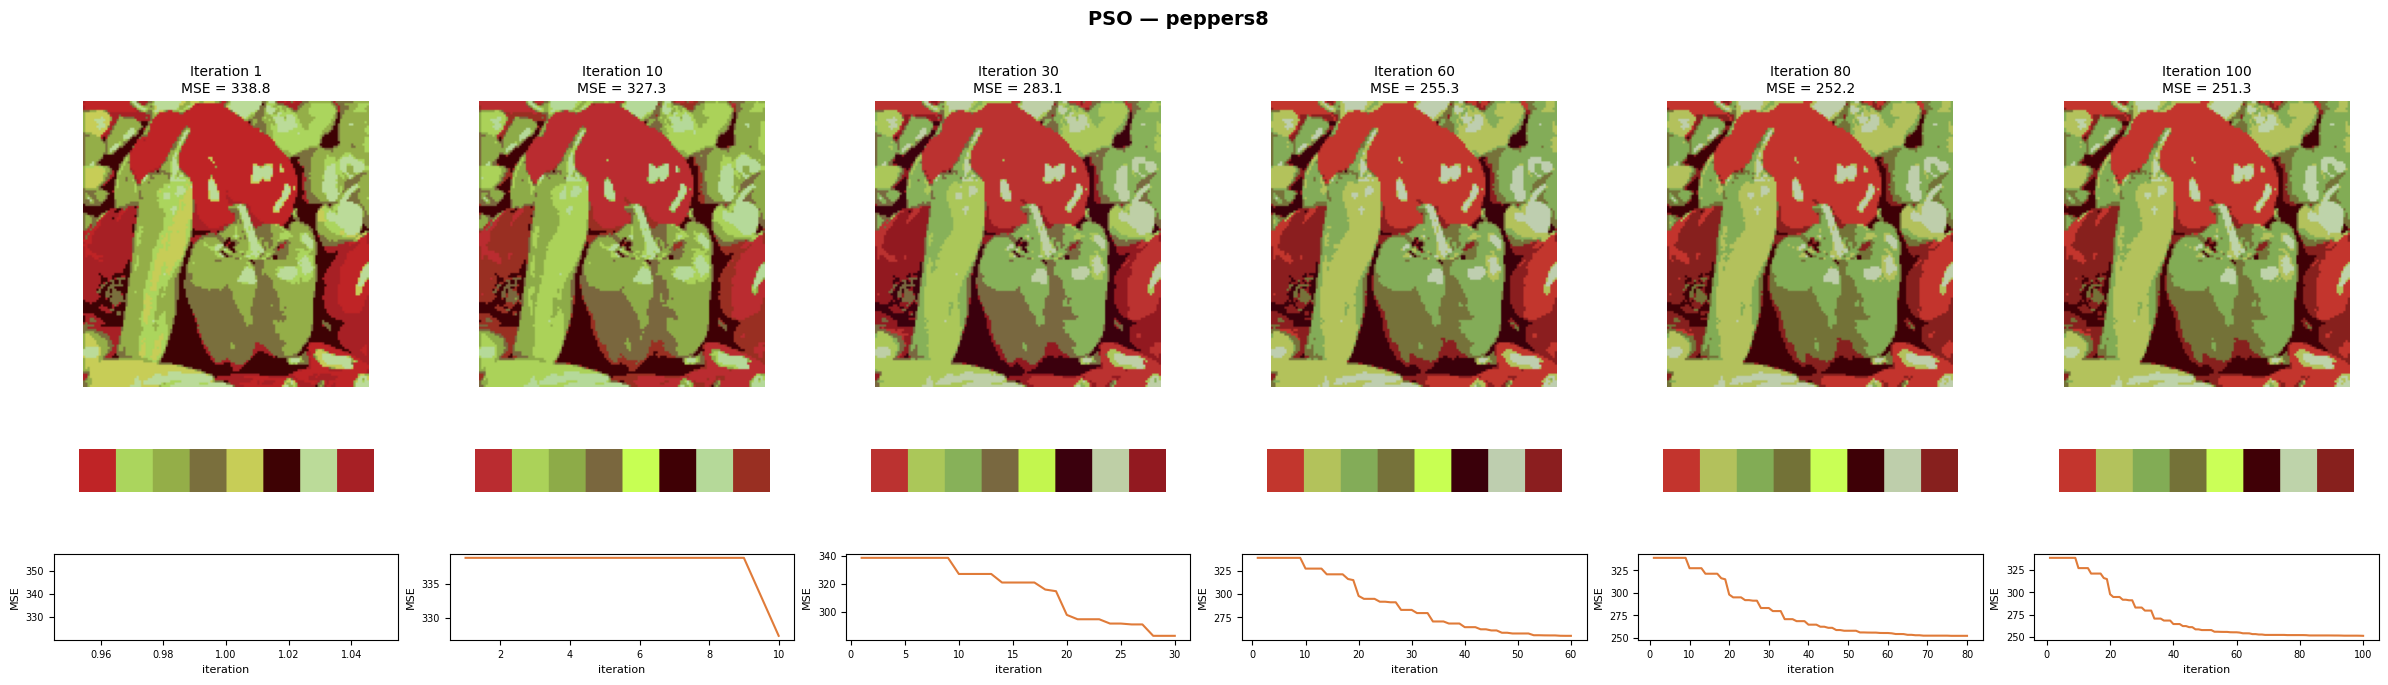

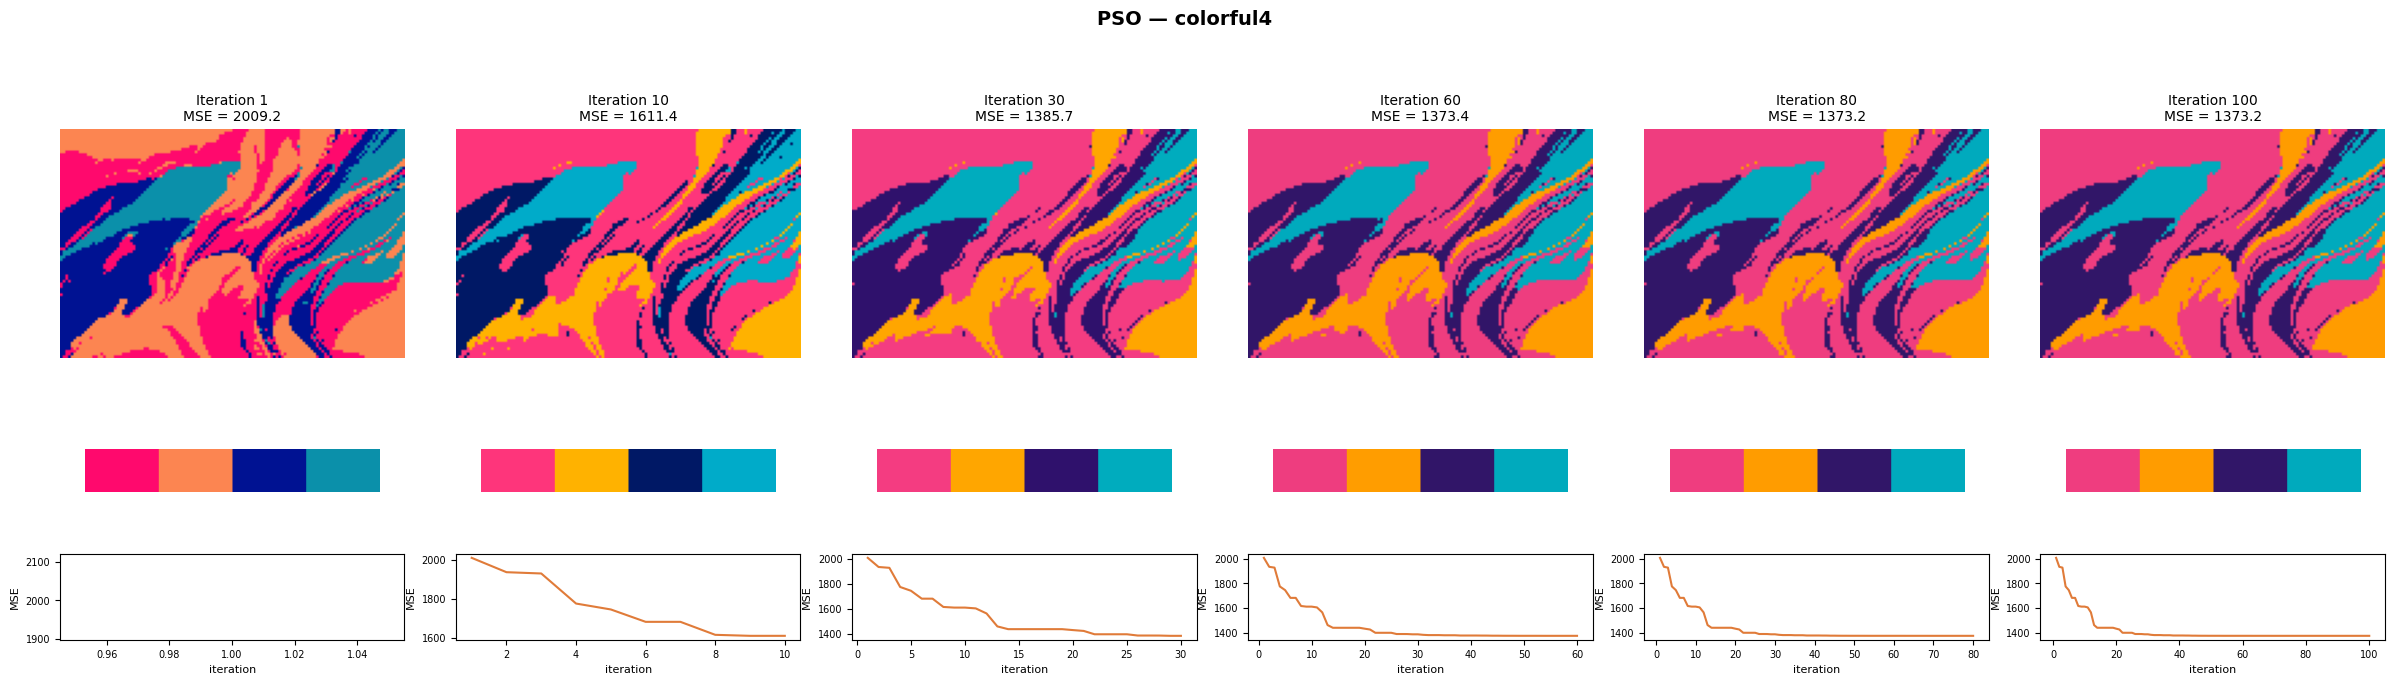

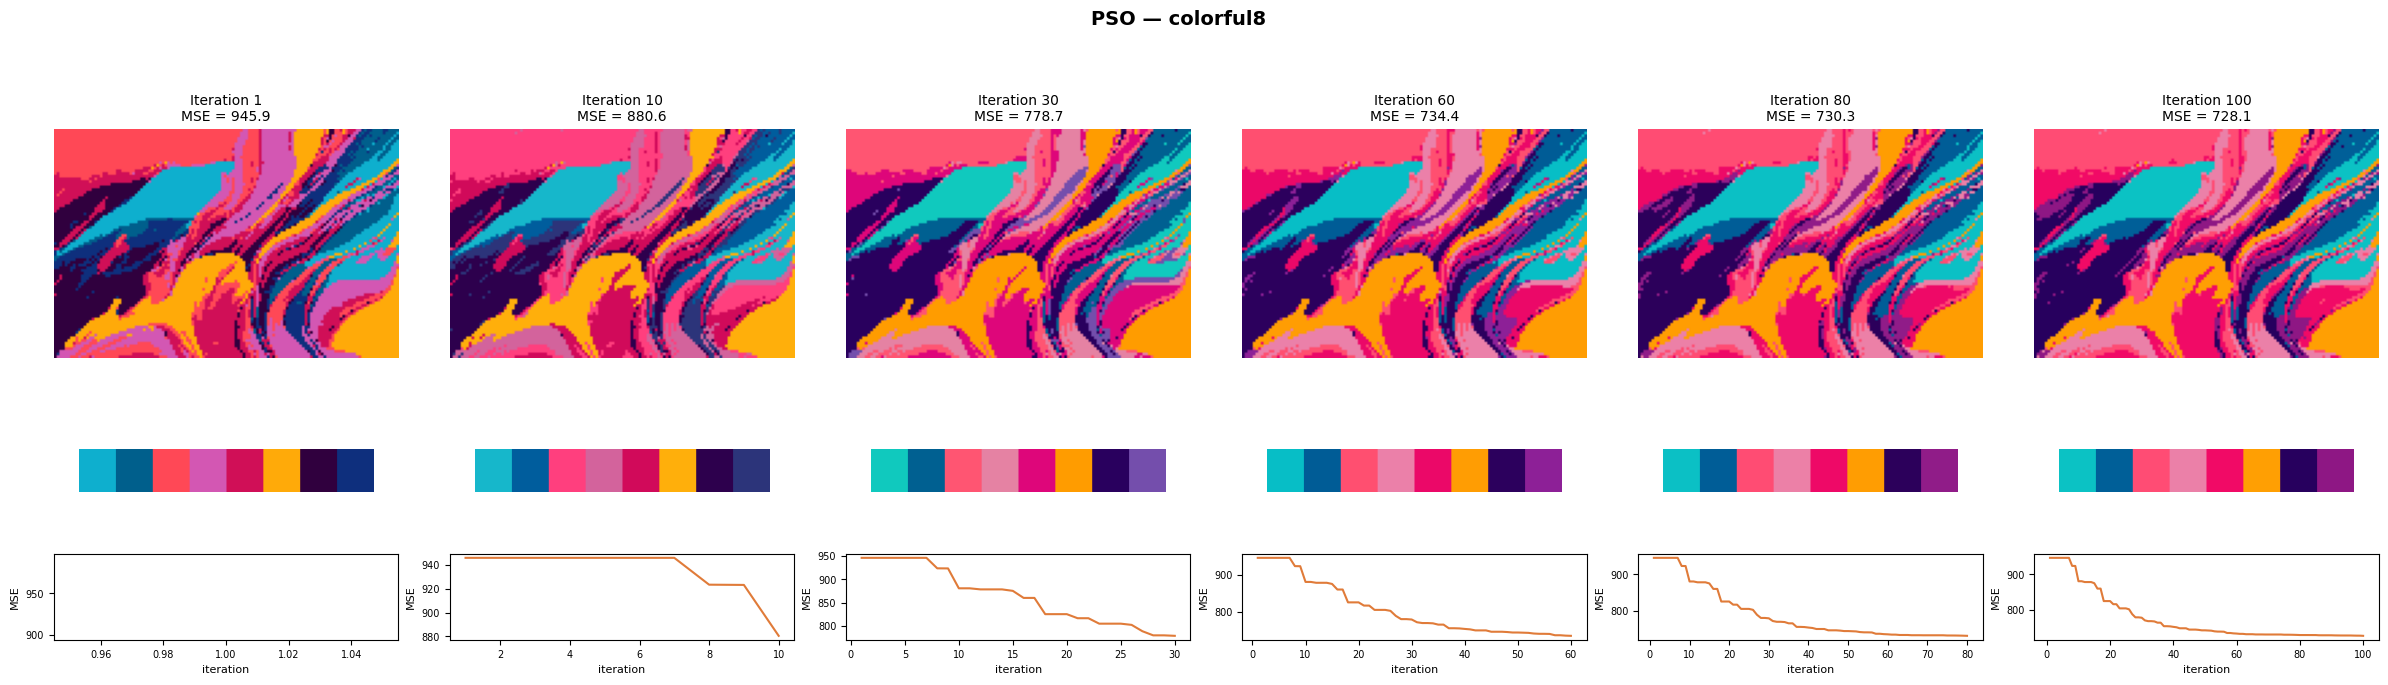

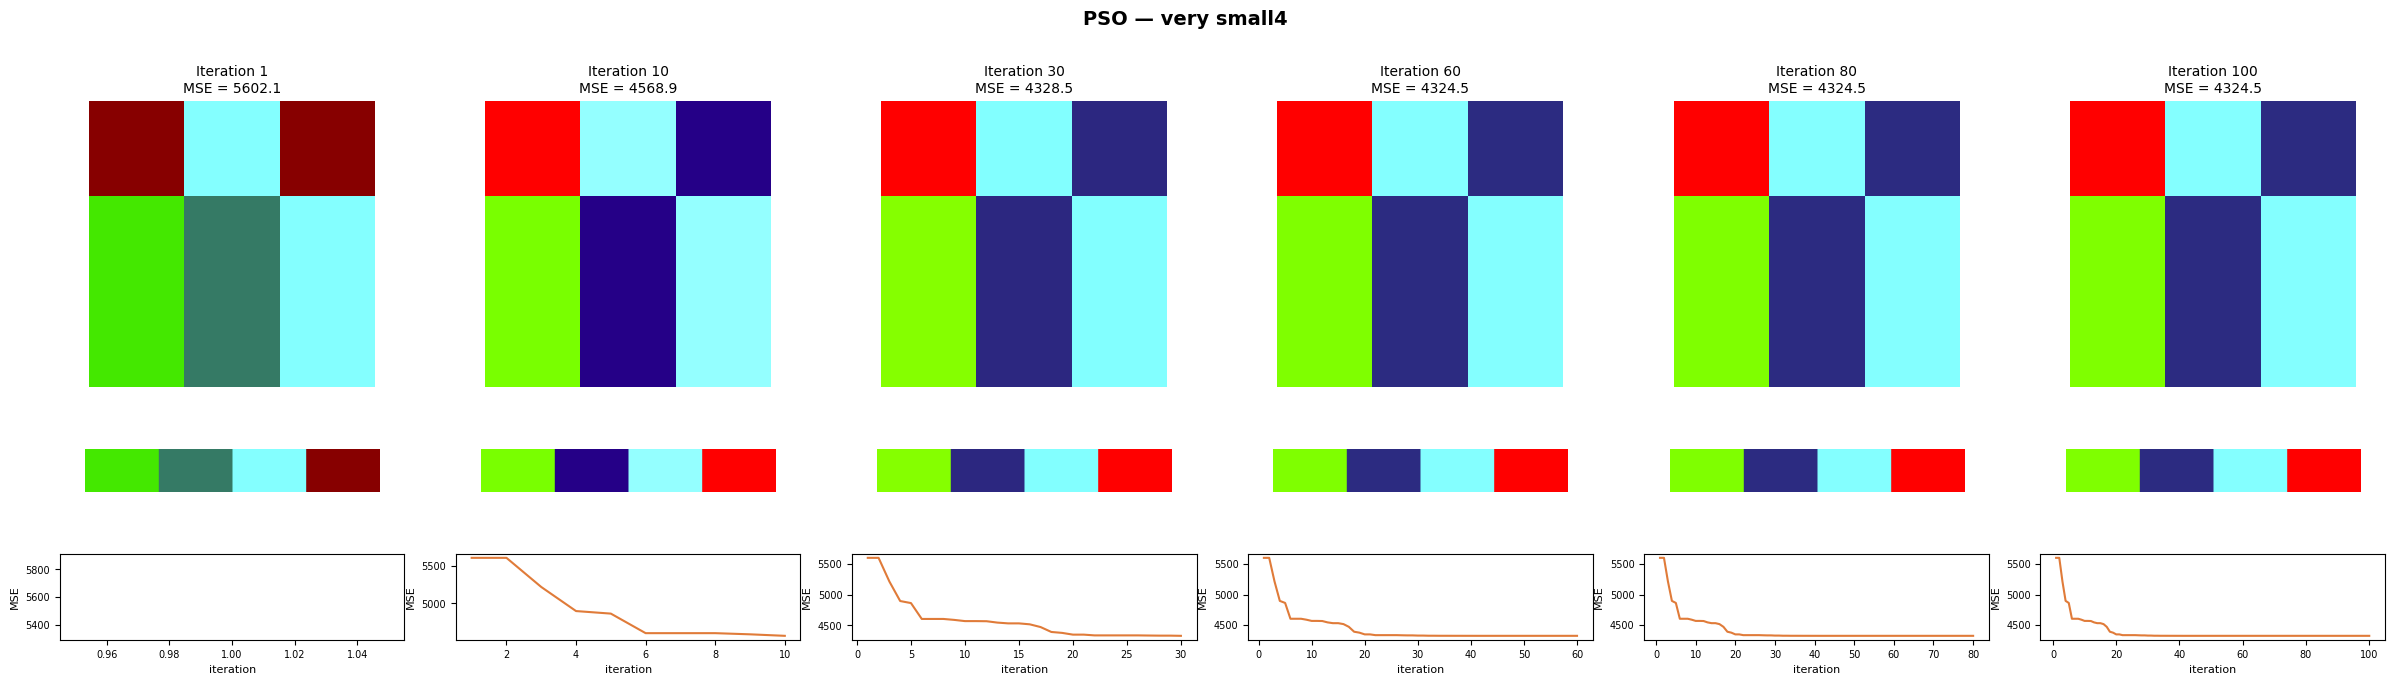

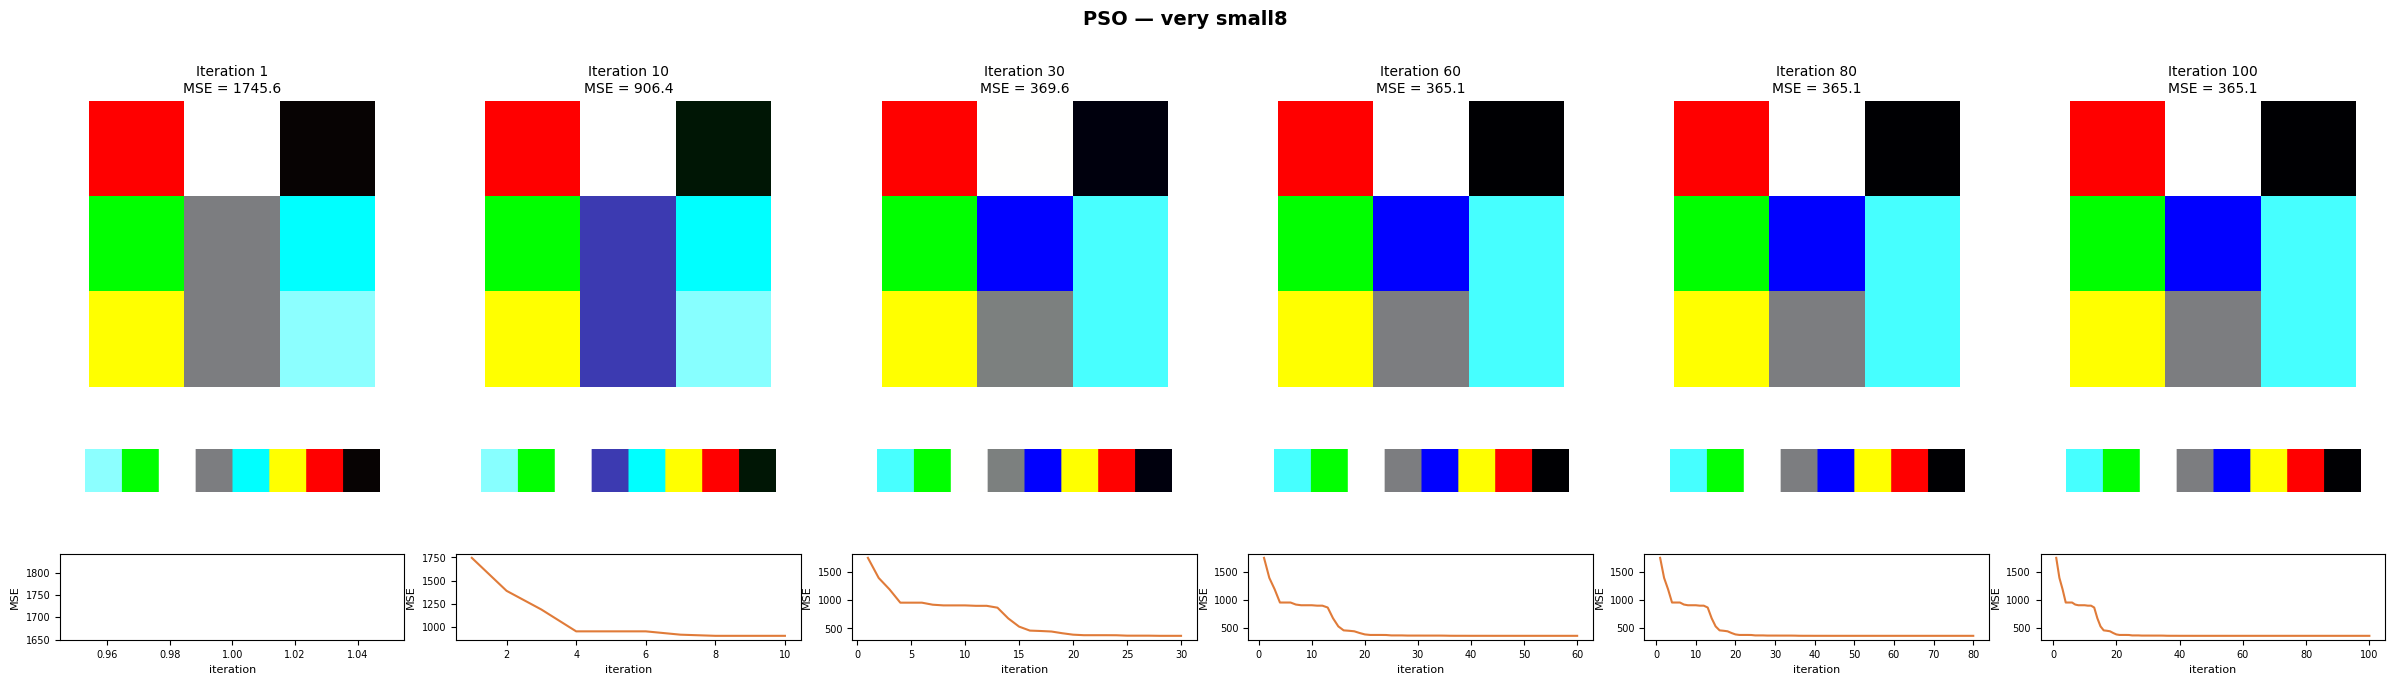

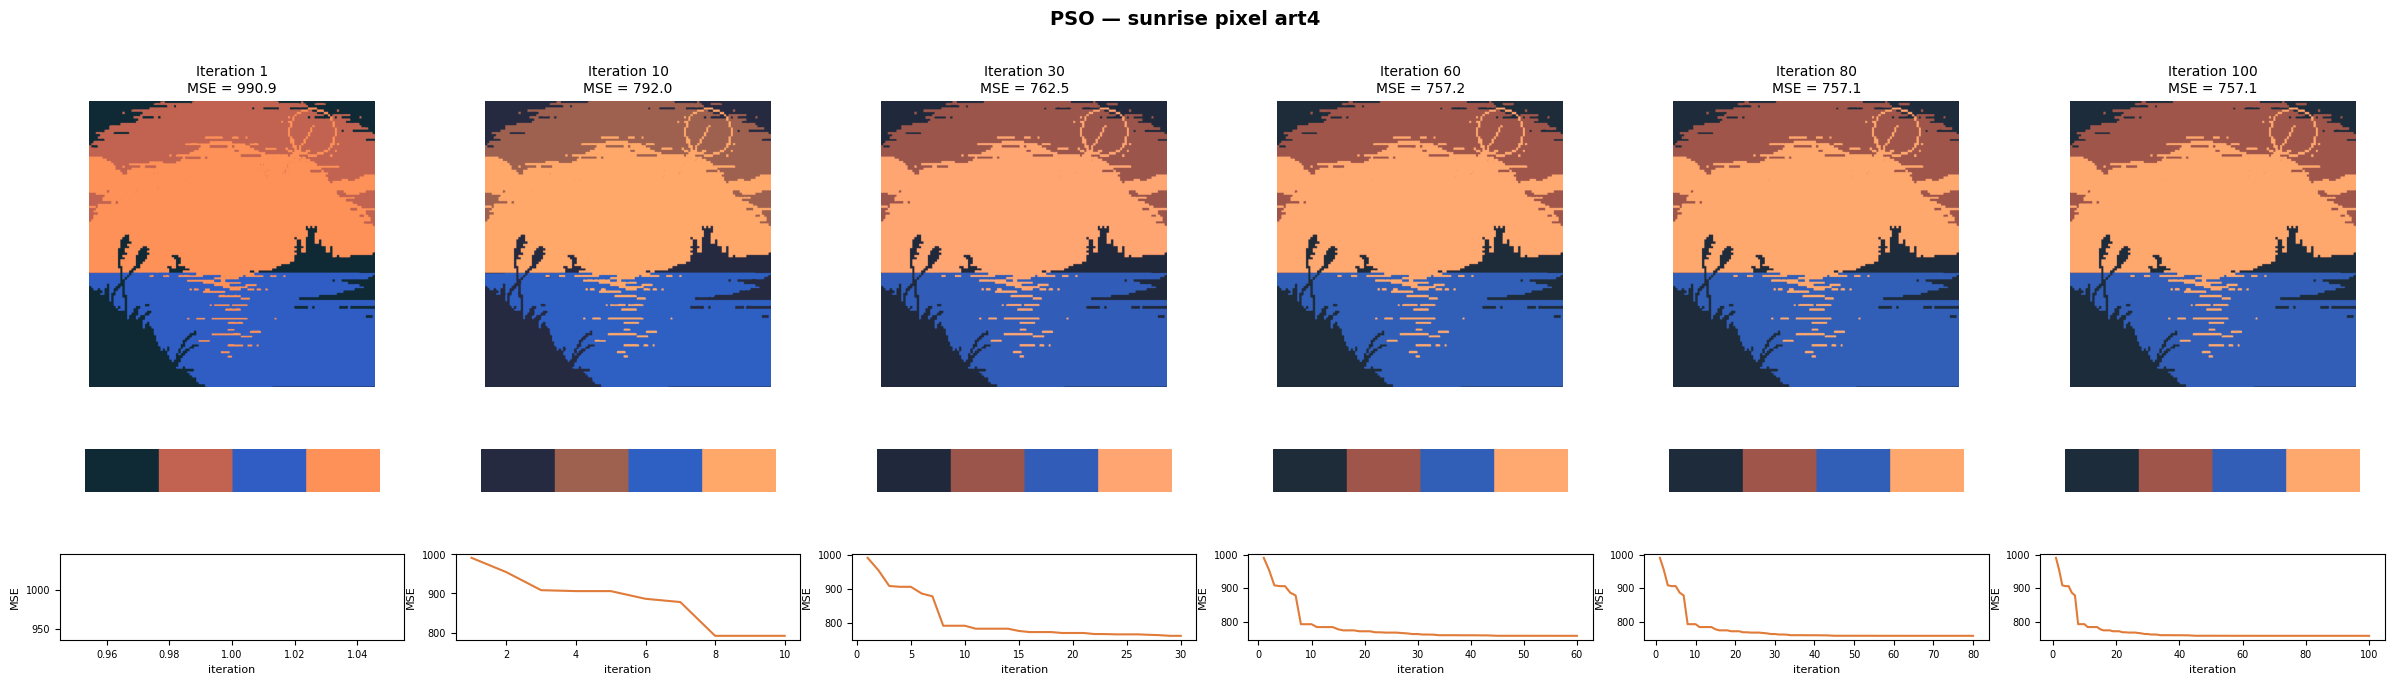

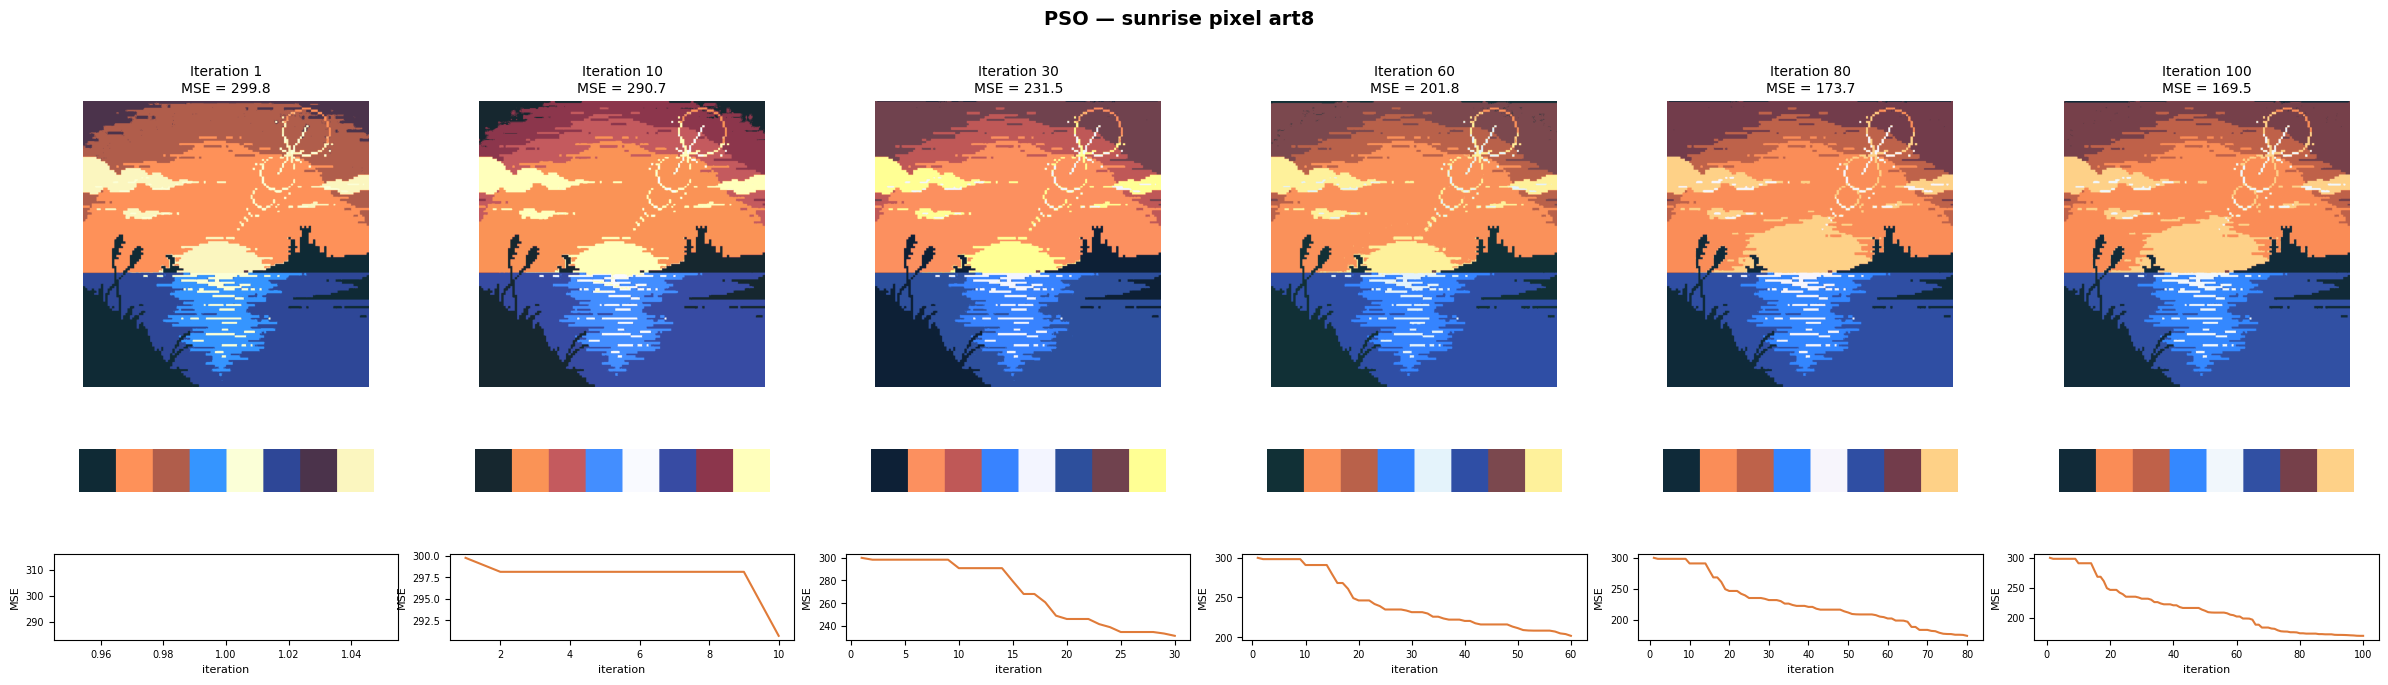

In [16]:
# ── Figure 1 & 2: PSO iteration snapshots ────────────────────────────────────

SNAP = [1, 10, 30, 60, 80, 100]
for r in results:
    fig = plot_pso_snapshots(r["pso"], r["img"], snapshots=SNAP,
                             title=f"PSO — {r['name']}")
    # fig.savefig(f"/mnt/user-data/outputs/pso_snapshots_{r['name'][:7].replace(' ','_')}.png",
                # dpi=130, bbox_inches="tight")
    # plt.close(fig)
    plt.show()


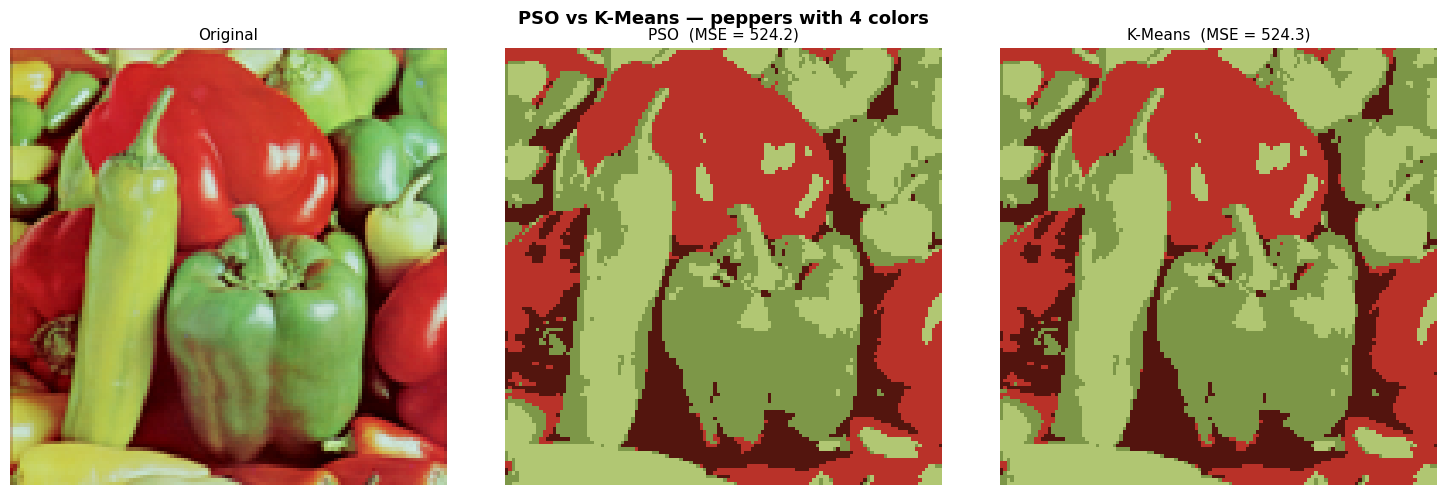

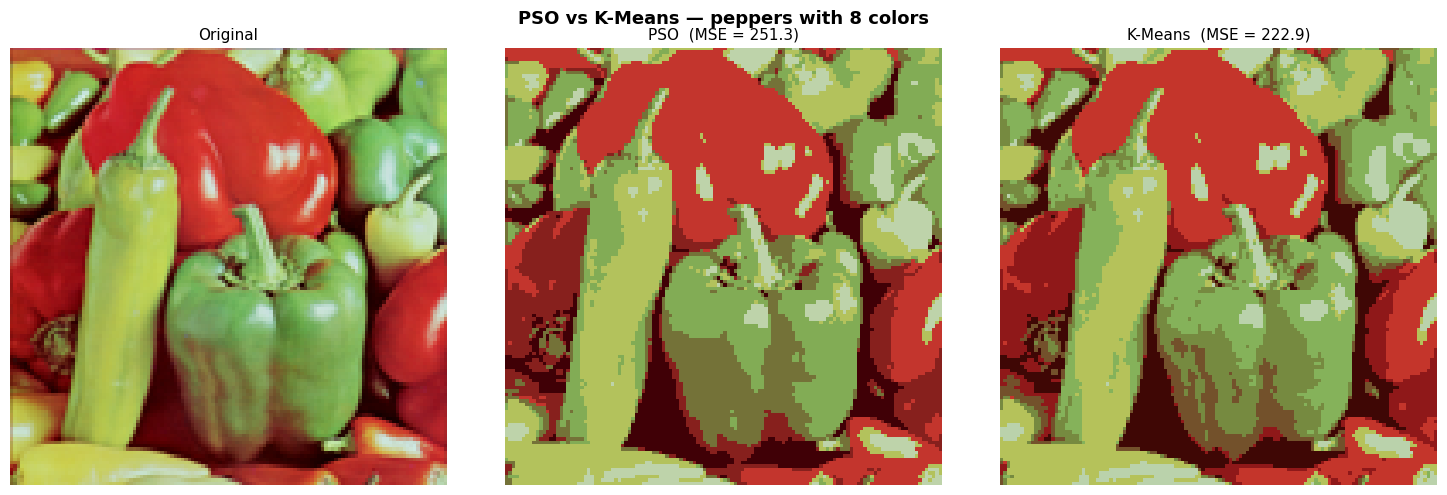

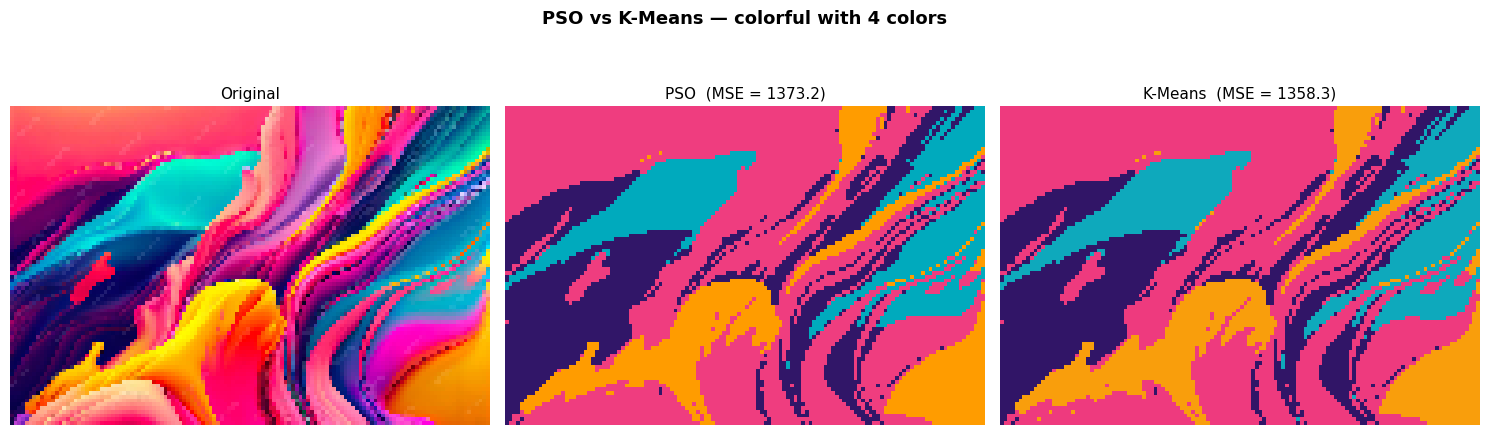

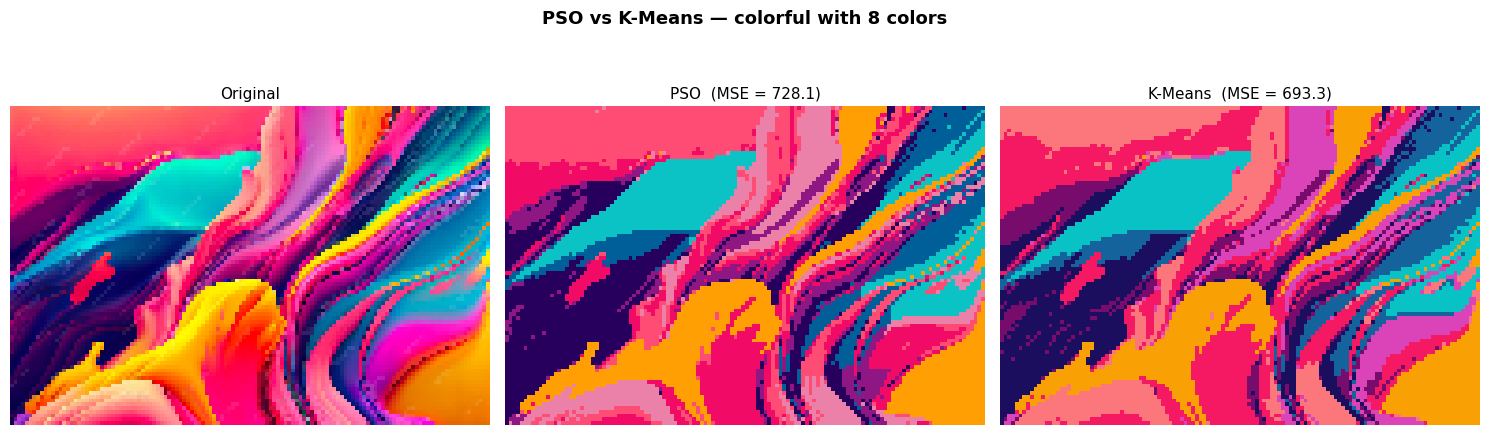

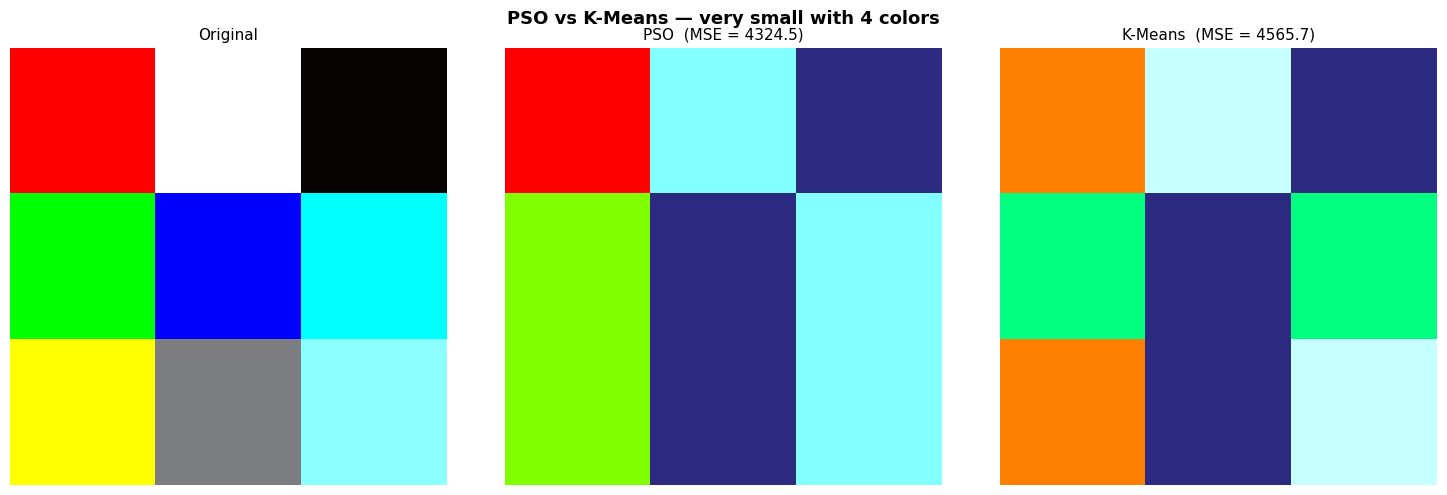

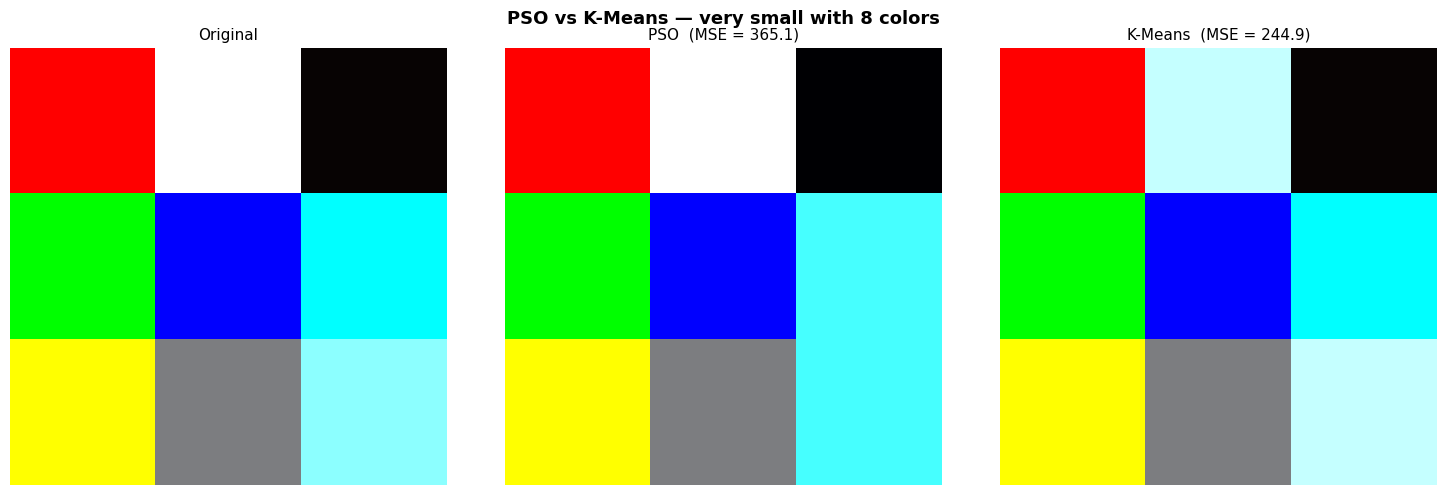

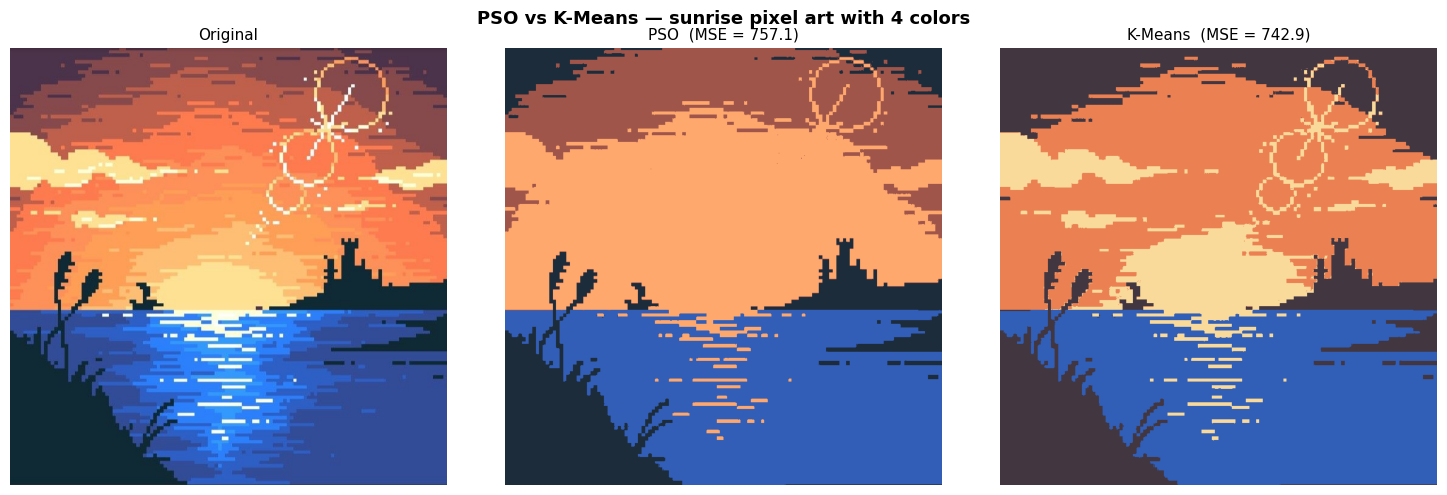

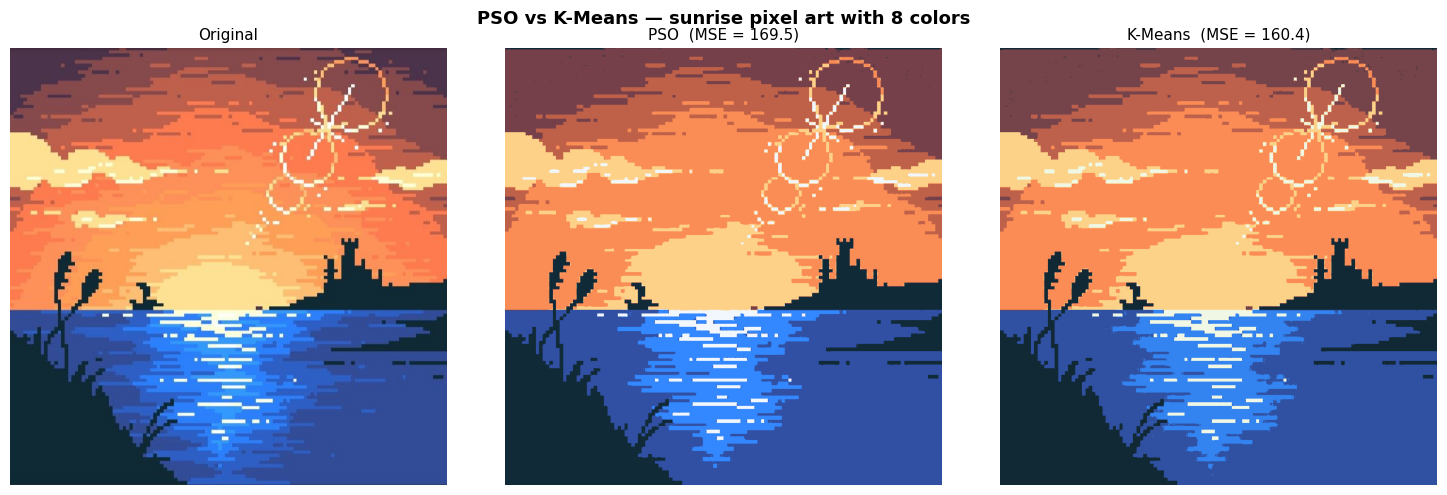

In [21]:
# ── Figure 3 & 4: PSO vs K-Means comparison ──────────────────────────────────

for r in results:
    fig = plot_comparison(r["img"], r["pso"], r["km_q"], r["km_pal"],
                          r["pso_mse"], r["km_mse"],
                          title=f"PSO vs K-Means — {r['name'][:-1]} with {r['name'][-1]} colors")
    # fig.savefig(f"/mnt/user-data/outputs/comparison_{r['name'][:7].replace(' ','_')}.png",
    #             dpi=130, bbox_inches="tight")
    # plt.close(fig)
    plt.show()


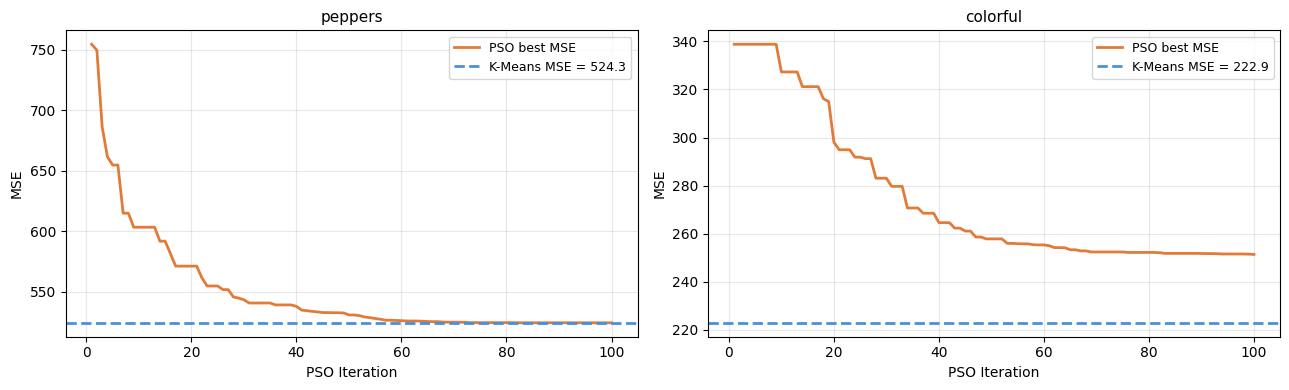

In [18]:
# ── Figure 5: convergence curves ─────────────────────────────────────────────

fig = plot_mse_curves(results[0]["pso"], results[1]["pso"],
                      results[0]["km_mse"], results[1]["km_mse"], img_titles)
# fig.savefig("/mnt/user-data/outputs/convergence_curves.png", dpi=130, bbox_inches="tight")
# plt.close(fig)
plt.show()

# print("\nAll figures saved to /mnt/user-data/outputs/")
